In [9]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [11]:
val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [12]:
########### concatenation
# concatenation of output from simaese network
class SiameseNetwork(nn.Module):

    def __init__(self, hidden_layer_neurons = 256 ):
        super(SiameseNetwork, self).__init__()
        model_path = "./pretrained_model/mobilefacenet_scripted.pt"
    
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # sets device for model and PyTorch tensors
        
        self.backbone = torch.jit.load(model_path, map_location=self.device)
        for param in self.backbone.parameters():
            param.requires_grad = False
#         self.bn = nn.BatchNorm1d(num_features=128) # 128 because the output of mobilefacenet is 128 dimensional
#         self.ln = nn.LayerNorm(128) # 128 because the output of mobilefacenet is 128 dimensional
        self.fc_classifier = nn.Sequential(
            nn.Linear(256, hidden_layer_neurons), # 1 hidden layer with 32 neurons
            nn.ReLU(),
#             nn.Linear(hidden_layer_neurons, hidden_layer_neurons//2), # 1 hidden layer with 32 neurons
#             nn.ReLU(),
#             nn.Dropout(p=0.5),
            nn.Linear(hidden_layer_neurons, 1),
            nn.Sigmoid()
        )
        self.mode = 'train' 
        

    def forward_once(self, x):
        output = self.backbone(x)
#         output = self.ln(output)
#         output = self.bn(output)
        return output
    
    def forward_train(self, data : dict):
        input1 = data['sample'].to(self.device)
        input2 = data['frame'].to(self.device)
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        output = torch.cat((output1, output2), 1)
        return output
    
    def forward_test(self, image):
        image = image.to(self.device)
        output2 = self.forward_once(image)
        output = torch.cat((self.sample, output2), 1)
        return output

    
    def forward(self, data):
        if self.mode == 'test':
            output = self.forward_test(data)
        else:
            output= self.forward_train(data)
        
        output = self.fc_classifier(output)
        return output
    
    def init(self, images): # initialization of sample images
        images = images.to(self.device)
        samples = self.forward_once(images)
        if samples.shape[0] == 1:
            self.sample = samples
        else:
            self.sample = samples.mean(axis=0).unsqueeze(0)

In [13]:
model = SiameseNetwork().to(device)

checkpoint_path = 'classifier_model/checkpoint.tar'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['weights'])

model.eval()
print("Model Ready")

Model Ready


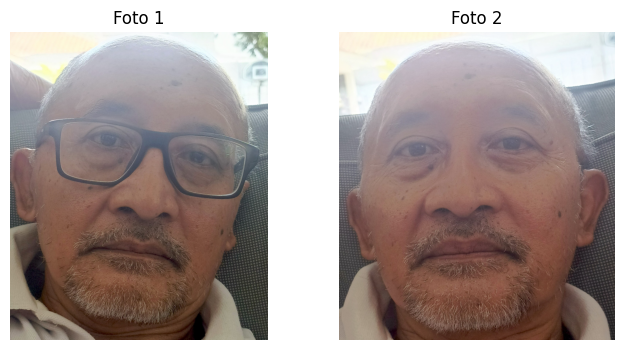

------------------------------
Skor Kecocokan : 61.84%
Kesimpulan     : ✅ INI ORANG YANG SAMA!
------------------------------


In [14]:
def face_match(img_path_1, img_path_2, threshold=0.5):
    # Buka foto
    img1 = Image.open(img_path_1).convert('RGB')
    img2 = Image.open(img_path_2).convert('RGB')
    
    # Pamerin fotonya bersandingan
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img1)
    ax[0].set_title("Foto 1")
    ax[0].axis('off')
    ax[1].imshow(img2)
    ax[1].set_title("Foto 2")
    ax[1].axis('off')
    plt.show()

    # Pre-processing & jadikan tensor [Batch, Channel, Height, Width]
    tensor1 = val_transform(img1).unsqueeze(0).to(device)
    tensor2 = val_transform(img2).unsqueeze(0).to(device)
    
    # Bungkus jadi format dictionary sesuai permintaan forward pass modelmu
    data = {'sample': tensor1, 'frame': tensor2}
    
    # Tebak!
    with torch.no_grad():
        output_prob = model(data)
        
    # Ambil angka probabilitasnya
    score = output_prob.item()
    
    print("-" * 30)
    print(f"Skor Kecocokan : {score * 100:.2f}%")
    
    if score >= threshold:
        print("Kesimpulan     : ✅ INI ORANG YANG SAMA!")
    else:
        print("Kesimpulan     : ❌ INI ORANG YANG BERBEDA!")
    print("-" * 30)

# --- CARA PAKAINYA ---
# Siapkan 2 foto (misal foto Ben Affleck dua-duanya, atau foto Ben dan Elton)
foto_tes_1 = "./dataset/inference_face_set/papa1.jpg" 
foto_tes_2 = "./dataset/inference_face_set/papa3.jpg"

# Eksekusi!
face_match(foto_tes_1, foto_tes_2)